In [1]:
import pandas as pd

df = pd.read_csv("Bank Customer Churn Prediction.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())

   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column    

# Package Setup & Reproducibility:

In [2]:
# ==========================
# PACKAGE IMPORTS
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ==========================
# REPRODUCIBILITY
# ==========================

np.random.seed(42)
tf.random.set_seed(42)

# Package versions

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)

Pandas: 2.3.3
NumPy: 2.3.5
TensorFlow: 2.21.0


# Loading Dataset:

In [10]:
try:
    df = pd.read_csv("Bank Customer Churn Prediction.csv")
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("""
    ERROR:
    bank_churn.csv not found.

    Place the file in the same folder as this notebook.
    """)

Dataset loaded successfully.


# Quick Data Exploration:

In [4]:
# First 5 rows

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [6]:
print("Shape:", df.shape)

Shape: (10000, 12)


In [7]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
df["churn"].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

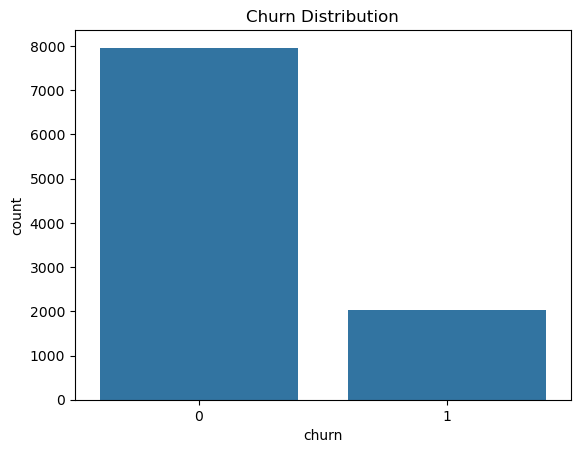

In [9]:
sns.countplot(x="churn", data=df)
plt.title("Churn Distribution")
plt.show()

# Missing Value Analysis:

In [11]:
missing_values = df.isnull().sum()

print(missing_values)

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


In [12]:
if missing_values.sum() == 0:
    print("No missing values found.")

No missing values found.


# Feature Selection:

In [13]:
df = df.drop("customer_id", axis=1)

# Categorical Encoding:

In [14]:
df = pd.get_dummies(
    df,
    columns=["country", "gender"],
    drop_first=True
)

# Createing Features & Target:

In [15]:
X = df.drop("churn", axis=1)

y = df["churn"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (10000, 11)
y Shape: (10000,)


# Train - Test - Split:

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Feature Scaling:

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Building ANN:

In [18]:
model = Sequential()

model.add(Dense(64, activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(32, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(16, activation="relu"))

model.add(Dense(1, activation="sigmoid"))

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile Model:

In [19]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Early Stopping:

In [20]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Train Model:

In [21]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7939 - loss: 0.4865 - val_accuracy: 0.8125 - val_loss: 0.4318
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8058 - loss: 0.4423 - val_accuracy: 0.8369 - val_loss: 0.4149
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8161 - loss: 0.4231 - val_accuracy: 0.8500 - val_loss: 0.3958
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8205 - loss: 0.4104 - val_accuracy: 0.8606 - val_loss: 0.3775
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8273 - loss: 0.4022 - val_accuracy: 0.8700 - val_loss: 0.3629
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8336 - loss: 0.3903 - val_accuracy: 0.8669 - val_loss: 0.3512
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8397 - loss: 0.3788 - val_accuracy: 0.8719 - val_loss: 0.3436
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8395 - loss: 0.3820 - val_a

# Training Curves:

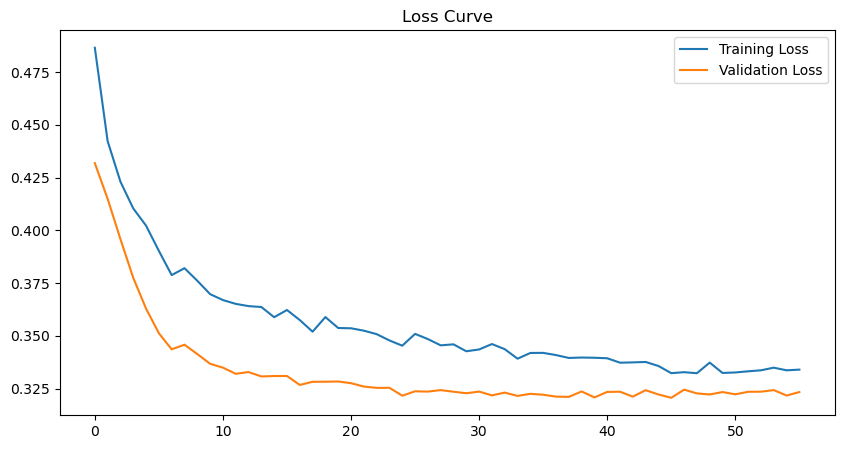

In [22]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.legend()
plt.title("Loss Curve")
plt.show()

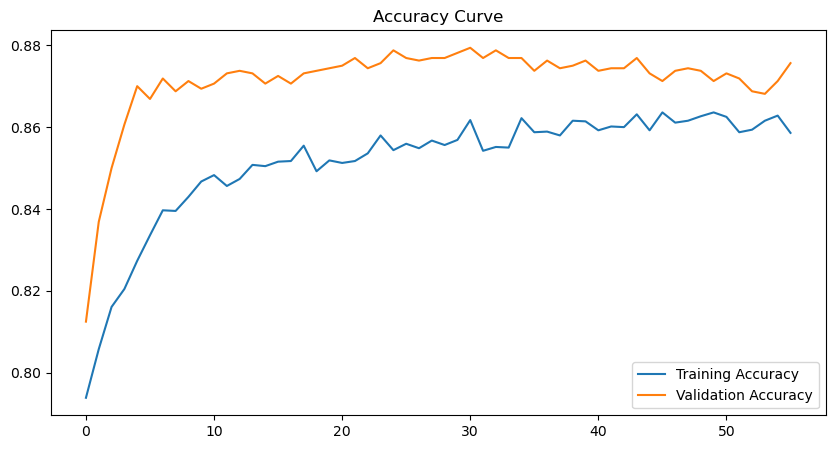

In [23]:
plt.figure(figsize=(10,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [24]:
y_prob = model.predict(X_test)

y_pred = (y_prob > 0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


# Evaluation Metrics:

In [25]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.864


In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



In [27]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8615287089863362


# Confusion Matrix:

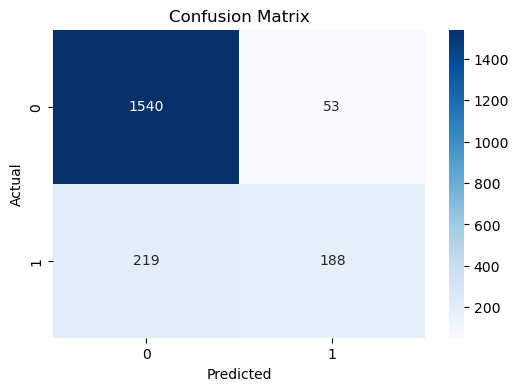

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# ROC Curve:

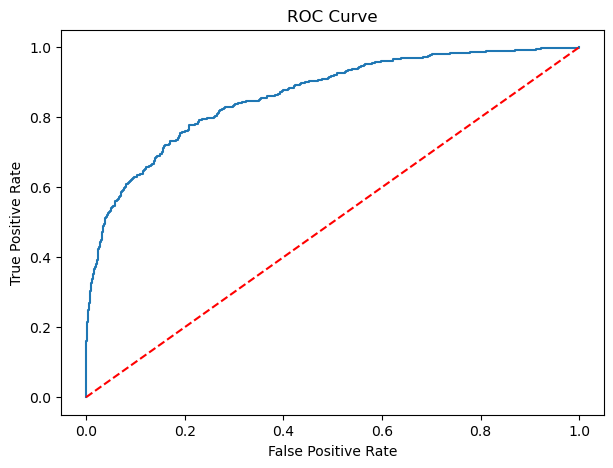

In [29]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

# Saveing Model:

In [31]:
model.save("bank_churn_ann.keras")

# Loading Model:

In [32]:
from tensorflow.keras.models import load_model

loaded_model = load_model("bank_churn_ann.keras")